#Load and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()  # upload walmart_clean.csv

Saving walmart_clean.csv to walmart_clean.csv


In [4]:
df = pd.read_csv('walmart_clean.csv', parse_dates=['Date'])
print("Shape:", df.shape)
df.head()

Shape: (420212, 21)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0


#Prepare Data

In [5]:
# Aggregate weekly total sales
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
weekly.columns = ['Date', 'Total_Sales']
weekly = weekly.sort_values('Date')

print("Weekly data shape:", weekly.shape)
weekly.head()

Weekly data shape: (143, 2)


,Date,Total_Sales
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


#Train Isolation Forest

In [6]:
# Scale the data
scaler = StandardScaler()
sales_scaled = scaler.fit_transform(weekly[['Total_Sales']])

# Train Isolation Forest
model_if = IsolationForest(
    contamination=0.05,  # expect 5% anomalies
    random_state=42,
    n_estimators=100
)

weekly['Anomaly'] = model_if.fit_predict(sales_scaled)
weekly['Anomaly_Score'] = model_if.score_samples(sales_scaled)

# -1 = anomaly, 1 = normal
weekly['Is_Anomaly'] = weekly['Anomaly'] == -1

print("Total weeks:", len(weekly))
print("Anomalies detected:", weekly['Is_Anomaly'].sum())
print("\nAnomaly dates:")
print(weekly[weekly['Is_Anomaly']][['Date', 'Total_Sales']])

Total weeks: 143
Anomalies detected: 8

Anomaly dates:
          Date  Total_Sales
42  2010-11-26  65821216.26
45  2010-12-17  61821317.85
46  2010-12-24  80931586.20
51  2011-01-28  39600376.50
94  2011-11-25  66593835.85
97  2011-12-16  60086723.16
98  2011-12-23  76999773.57
113 2012-04-06  53502476.06


#Visualize Anomalies

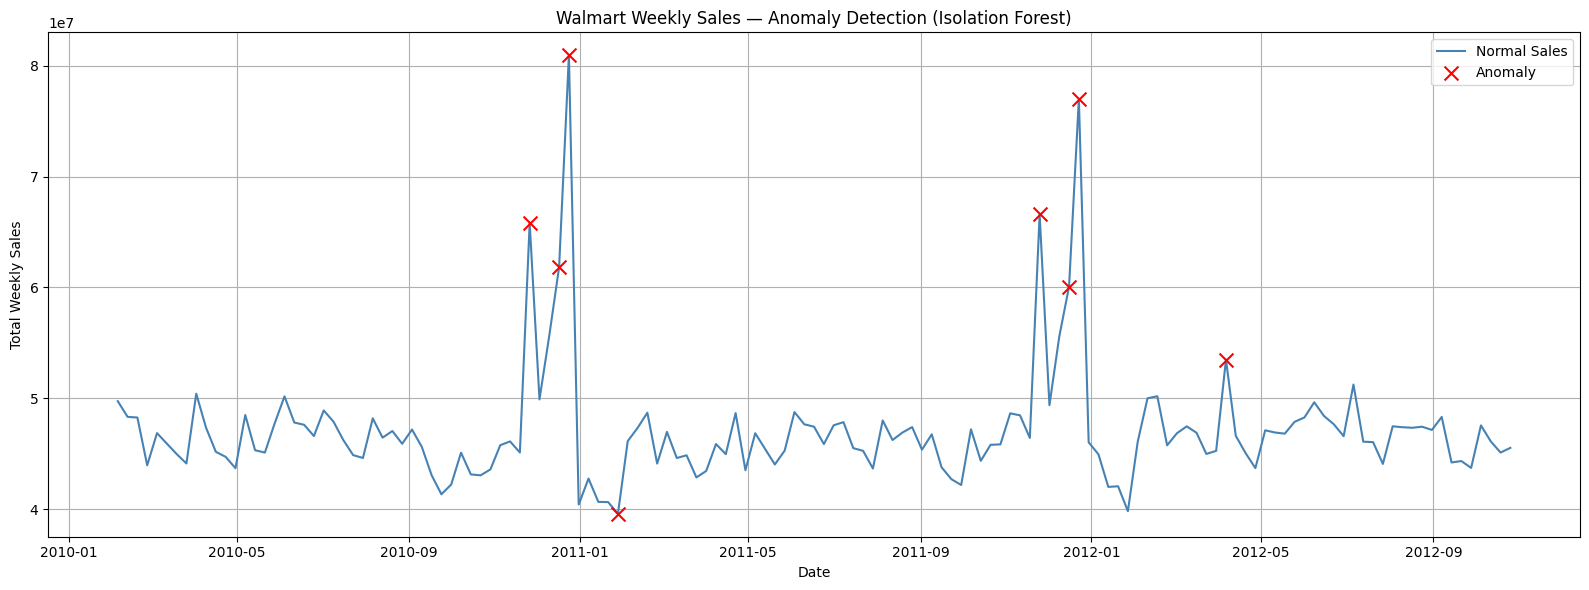

In [7]:
plt.figure(figsize=(16, 6))

# Normal points
plt.plot(weekly['Date'], weekly['Total_Sales'],
         color='steelblue', label='Normal Sales', linewidth=1.5)

# Anomaly points
anomalies = weekly[weekly['Is_Anomaly']]
plt.scatter(anomalies['Date'], anomalies['Total_Sales'],
            color='red', s=100, zorder=5, label='Anomaly', marker='x')

plt.title('Walmart Weekly Sales — Anomaly Detection (Isolation Forest)')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150)
plt.show()

#Anomaly Score Plot

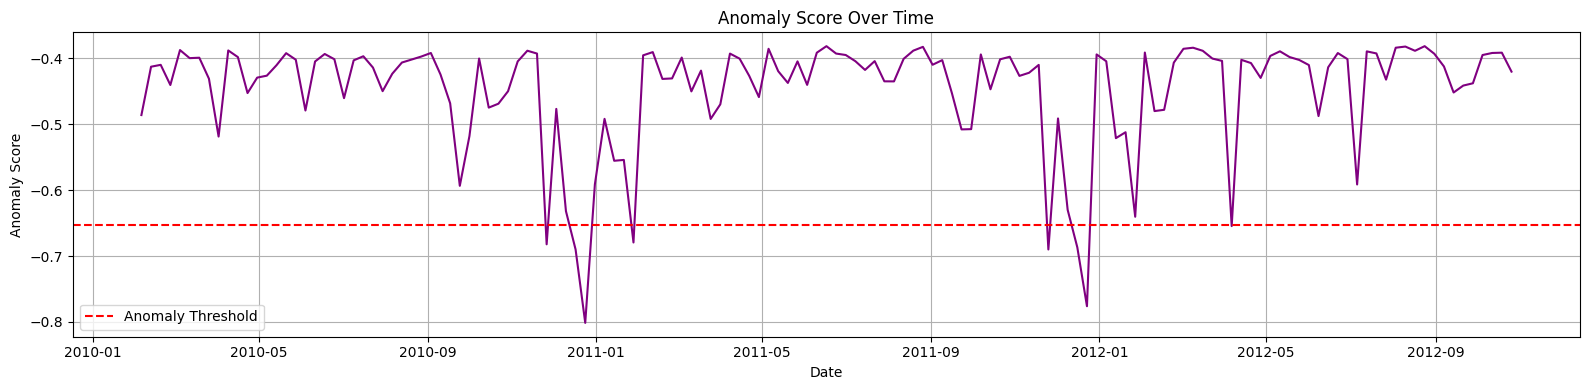

In [8]:
plt.figure(figsize=(16, 4))
plt.plot(weekly['Date'], weekly['Anomaly_Score'],
         color='purple', linewidth=1.5)
plt.axhline(y=weekly['Anomaly_Score'].quantile(0.05),
            color='red', linestyle='--', label='Anomaly Threshold')
plt.title('Anomaly Score Over Time')
plt.xlabel('Date')
plt.ylabel('Anomaly Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('anomaly_scores.png', dpi=150)
plt.show()

#Save Model

In [9]:
joblib.dump(model_if, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Models saved!")

Models saved!
